In [1]:
import os
os.chdir('../../../../..')

In [32]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN, KMeans
from kmedoids import KMedoids
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster

In [3]:
qm9 = QM9Dataset(limit=5000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"], descriptors=["transformer"])
df = qm9.load()

2026-04-27 10:38:18.623 | INFO     | src.datasets:load:818 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-27 10:38:19.381 | INFO     | src.datasets:_sample_qm9_df:1018 - QM9 sampling complete: strategy=stratified, requested_limit=5000, returned_rows=5000.
2026-04-27 10:38:19.383 | INFO     | src.datasets:_add_requested_descriptors:199 - Applying requested QM9 descriptors to sampled dataframe (rows=5000).
2026-04-27 10:38:19.383 | INFO     | src.features:compute_selfies_transformer:169 - Computing SELFormer Embeddings using HUBioDataLab/SELFormer...
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/HUBioDataLab/SELFormer/177d98b158e999a6cb7fc9743dbfe1e8a17c57e5/config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/main/tokenizer_config.json "HTTP/1.

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/commits/main "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/discussions?p=0 "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/commits/refs%2Fpr%2F1 "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/refs%2Fpr%2F1/model.safetensors.index.json "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/refs%2Fpr%2F1/model.safetensors "HTTP/1.1 302 Found"
2026-04-27 10:39:50.476 | INFO     | src.datasets:_add_requested_descriptors:224 - Added descriptor column(s): ['selfies_transformer']


In [4]:
len(df['selfies_transformer'].to_list()[0])

768

In [5]:
molecules = qm9.get_molecules()

2026-04-27 10:40:46.889 | SUCCESS  | src.datasets:get_molecules:1588 - Saved 5000 molecules to data/QM9/qm9_subset.xyz (failed: 0, requested: 5000).


In [6]:
plot_molecules_with_py3dmol(molecules[0:3])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [7]:
dist_matrix = qm9.get_distance_matrix(
    descriptor="transformer",
    dist_type="euclidean",
    force_calculate=True,
)

2026-04-27 10:40:47.034 | INFO     | src.datasets:get_distance_matrix:1419 - Calculating distance matrix for selfies_transformer using euclidean distance.
2026-04-27 10:40:54.644 | SUCCESS  | src.distance:_compute_and_save:74 - Saved distance matrix to data/QM9/dist_selfies_transformer_euclidean.npy


# Determining the best number of clusters for each clustering method

Evaluating epsilon and min samples: 100%|██████████| 10/10 [00:09<00:00,  1.04it/s]


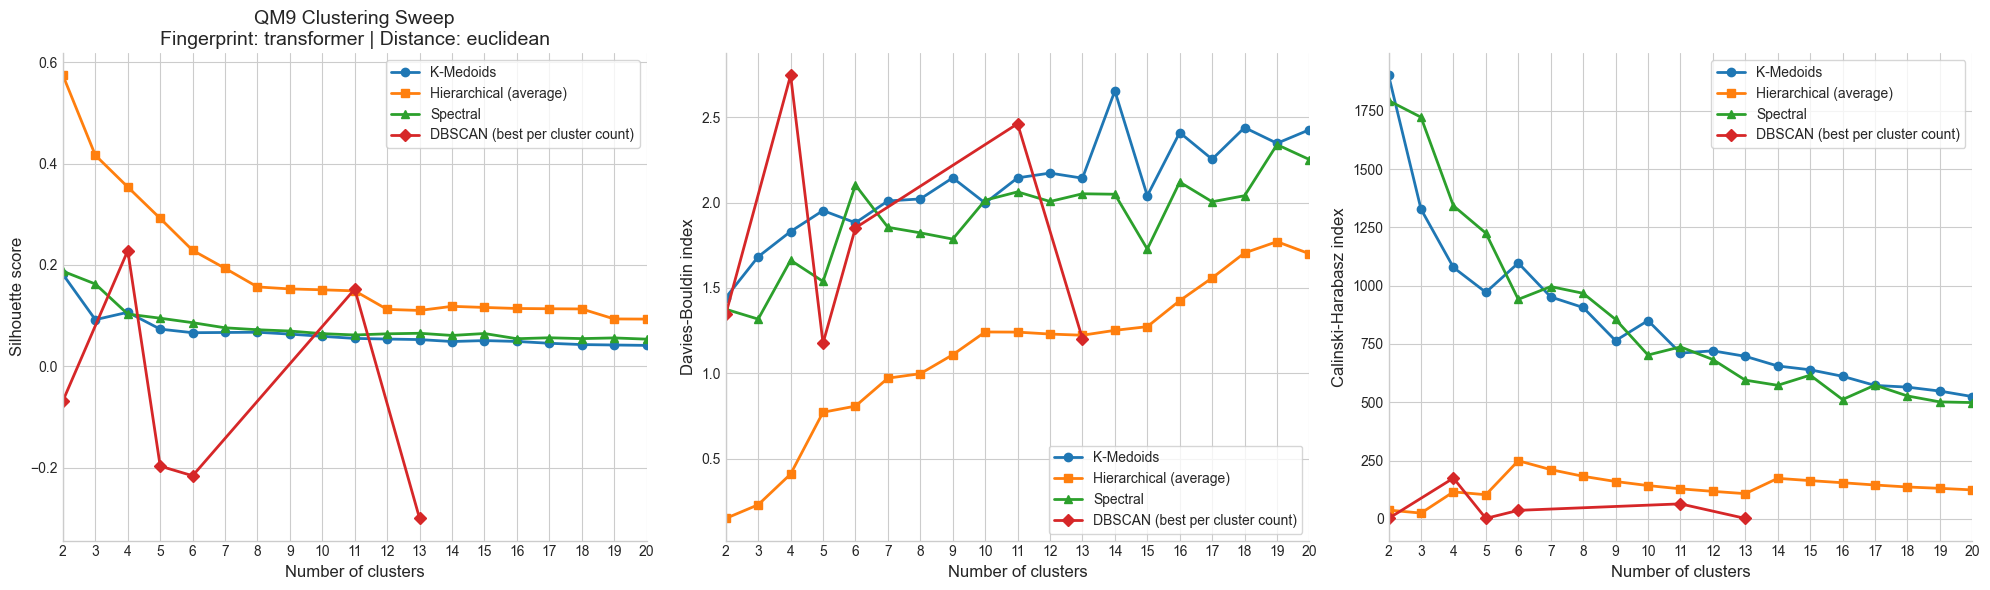

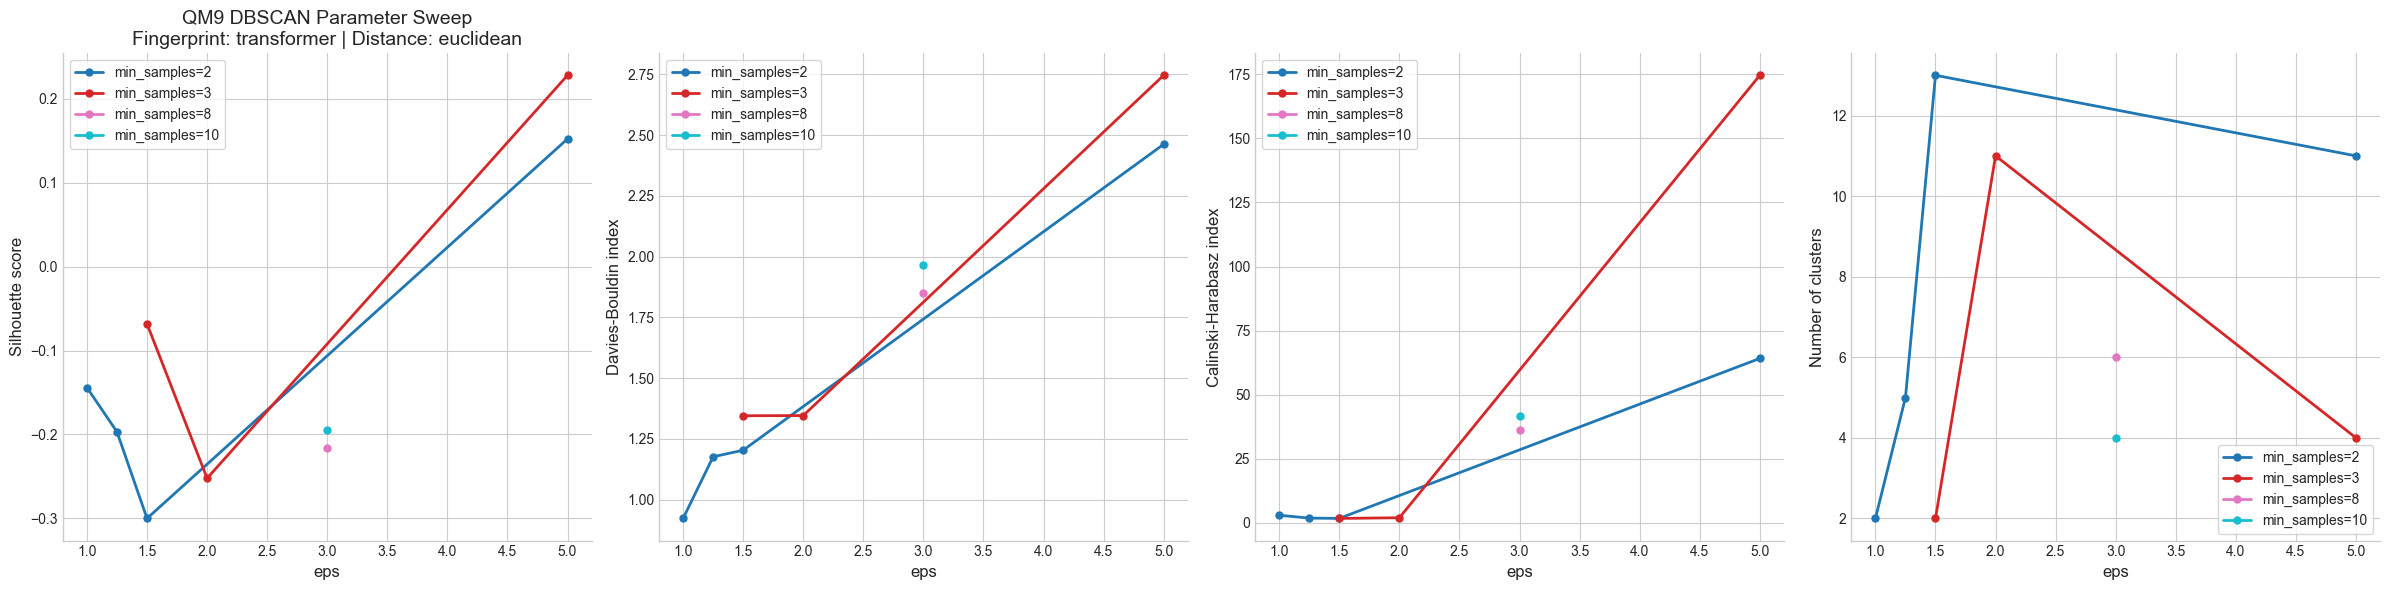

2026-04-27 10:43:08.904 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:984 - Saved clustering sweep plot to figures/qm9/clustering/euclidean/transformer/clustering_sweep_2_to_20_clusters.png
2026-04-27 10:43:08.905 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:986 - Saved DBSCAN evaluation plot to figures/qm9/clustering/euclidean/transformer/dbscan_parameter_sweep.png
2026-04-27 10:43:08.905 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:987 - Saved clustering sweep results to figures/qm9/clustering/euclidean/transformer/clustering_sweep_2_to_20_clusters.json


In [8]:
out = evaluate_distance_matrix_clustering_sweep(
    dist_matrix=dist_matrix,
    fingerprint="transformer",
    distance_metric="euclidean",
    dataset_name="qm9",
)

In [9]:
# find the n molecules that are not on the diagonal with the smallest distance
n = 10
# Get the indices of the upper triangle (excluding diagonal)
triu_indices = np.triu_indices_from(dist_matrix, k=1)
# Get the distances and corresponding molecule pairs
distances = dist_matrix[triu_indices]
molecule_pairs = list(zip(triu_indices[0], triu_indices[1]))
# Get the indices of the n smallest distances
smallest_indices = np.argsort(distances)[:n]
# Get the corresponding molecule pairs for the n smallest distances
closest_pairs = [molecule_pairs[i] for i in smallest_indices]
print("Closest molecule pairs (indices):", closest_pairs)
mols = [(molecules[idx1], molecules[idx2]) for idx1, idx2 in closest_pairs]

Closest molecule pairs (indices): [(np.int64(3769), np.int64(4441)), (np.int64(4944), np.int64(4961)), (np.int64(4227), np.int64(4540)), (np.int64(294), np.int64(4575)), (np.int64(4342), np.int64(4343)), (np.int64(2201), np.int64(3277)), (np.int64(4575), np.int64(4610)), (np.int64(403), np.int64(4227)), (np.int64(3457), np.int64(3484)), (np.int64(4424), np.int64(4577))]


In [10]:
print(mols[0])

(Atoms(symbols='H9C3H3C3H2O2C', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='H9CH3C3H2C2O2C', pbc=False, initial_charges=..., mass=..., partial_charge=...))


In [11]:
plot_molecules_with_py3dmol(mols[1])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Hiercical Clustering on Distance Matrix

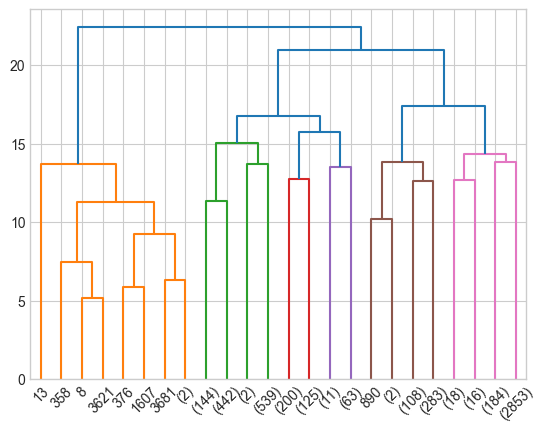

In [35]:
condensed_dist = squareform(dist_matrix)
Z = linkage(condensed_dist, method='complete')
a = dendrogram(
    Z,
    truncate_mode='level',
    p=4                 
)

In [36]:
model_hier = AgglomerativeClustering(metric='precomputed', n_clusters=6, linkage='complete')
labels_hier = model_hier.fit_predict(dist_matrix)
print(np.unique(labels_hier, return_counts=True))
df = df.with_columns(labels_hier=labels_hier)

(array([0, 1, 2, 3, 4, 5]), array([1127,  394, 3071,    9,   74,  325]))


In [37]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [38]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="transformer",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

2026-04-27 10:51:15.141 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:529 - Saved PCA projection plot to figures/qm9/clustering/euclidean/transformer/pca_hierarchical_projection.png


{'coords': array([[  6.54570685,  55.30561573],
        [-11.61597541,  81.89018437],
        [ 11.1666664 , -32.52514598],
        ...,
        [-24.28567977,   9.87986913],
        [ 10.82068599,  23.25097382],
        [ 25.95622588,   2.99963898]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/transformer/pca_hierarchical_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/transformer'),
 'clustering_method': 'hierarchical'}

In [39]:
average_numeric_by_cluster(df, "labels_hier")

shape: (6, 75)
┌─────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────────┬────────┬────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

labels_hier,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_km,labels_spectral,labels_db,labels_kmeans_raw,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,1127,2.053656,0.0,122.666371,0.012422,36.526176,0.898326,12.827073,8.763975,1.993789,0.088731,0.011535,2.404614,18.190772,2.09416,2.086957,0.068454,0.150613,0.780933,1.004437,2.053239,6.374445,0.449867,0.861579,5.047915,6.330967,37.638864,1.268148,0.001775,0.532387,0.015084,0.073647,0.050577,0.0,0.025732,0.086957,0.720497,0.0,2.398557,73.922422,-6.567682,0.594292,7.161923,1138.444408,4.014685,-11227.118642,-11226.896143,-11226.870433,-11228.015495,30.91046,-75.235889,-75.701616,-76.134877,-69.999425,3.402753,1.466339,1.185131,0.919255,0.0,-0.984028,1.086069,85.714286,8.251996,6.033718,37.638864,538,"""Acyclic""",6.033718,178,"""C1CC2CC12""",9.050577,1,null,0.0
1,394,1.795309,0.0,122.07868,-0.058376,60.22335,0.682025,12.991928,8.741117,0.959391,0.725888,0.096447,3.850254,14.672589,1.994881,2.032995,0.084784,0.667555,0.247661,1.269036,3.035533,5.510152,0.456853,3.19797,1.236041,6.398477,26.520305,1.258015,0.005076,0.180203,0.149746,0.357868,0.182741,0.005076,0.053299,0.081218,0.243655,0.005076,3.473743,69.87165,-6.395366,-0.830976,5.564404,1165.252268,2.977111,-11873.404311,-11873.185572,-11873.159901,-11874.306064,29.016804,-64.282287,-64.624659,-64.973095,-59.990543,3.906587,1.384625,1.006176,1.908629,0.0,-1.0,1.939086,14.974619,68.527919,16.497462,26.520305,141,"""Acyclic""",16.497462,27,"""C1CCCC1""",38.57868,1,null,0.0
2,3071,2.080137,0.0,123.129925,0.15337,33.636926,0.865087,12.855596,8.795832,1.452621,0.13774,0.023445,2.287854,19.083035,2.039828,2.544448,0.064931,0.202234,0.732835,0.835233,1.863237,6.676653,0.437968,1.228264,4.841745,6.424943,39.952133,1.257883,0.003582,0.283947,0.018235,0.143601,0.139368,0.001954,0.038098,0.141648,0.490068,0.001303,2.69601,76.93944,-6.546225,0.335012,6.881204,1241.846127,4.284376,-11068.333044,-11068.092027,-11068.066321,-11069.255822,32.75945,-78.735396,-79.218044,-79.674957,-73.255751,3.386212,1.33019,1.068818,0.593292,0.000977,-0.941387,0.436014,74.242918,13.741452,12.01563,39.952133,921,"""Acyclic""",12.01563,216,"""C1CCCC1""",13.253012,1,null,0.0
3,9,1.430383,0.0,100.333333,0.0,35.888889,0.874448,12.433241,7.666667,0.0,0.0,0.0,1.666667,11.333333,1.81718,0.888889,0.796825,0.018519,0.184656,0.666667,1.666667,1.444444,4.777778,0.111111,1.111111,6.444444,16.444444,1.242615,0.0,0.444444,0.0,0.222222,0.0,0.0,0.0,0.111111,0.111111,0.0,2.773133,67.637778,-7.612839,-1.022846,6.589993,1103.981072,2.048957,-9129.813368,-9129.592611,-9129.56684,-9130.692817,28.166445,-53.676573,-53.892734,-54.158266,-50.438001,68877.608099,1.558877,1.225548,1.666667,0.0,-1.0,2.0,0.0,0.0,100.0,16.444444,1,"""Acyclic""",100.0,1,"""Acyclic""",100.0,1,null,0.0
4,74,1.635533,0.0,118.959459,0.067568,63.594595,0.615904,12.989234,8.567568,1.243243,0.972973,0.054054,4.337838,12.067568,2.038564,1.067568,0.069144,0.864414,0.066441,0.594595,3.7

# KMedoids

In [16]:
model_km = KMedoids(n_clusters=3, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
print(np.unique(labels_km, return_counts=True))
df = df.with_columns(labels_km=labels_km)

(array([0, 1, 2], dtype=uint64), array([2225, 1492, 1283]))


In [17]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [40]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="transformer",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_km,
    clustering_method="kmedoids"
)

2026-04-27 11:00:57.016 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:529 - Saved PCA projection plot to figures/qm9/clustering/euclidean/transformer/pca_kmedoids_projection.png


{'coords': array([[  6.54570685,  55.30561573],
        [-11.61597541,  81.89018437],
        [ 11.1666664 , -32.52514598],
        ...,
        [-24.28567977,   9.87986913],
        [ 10.82068599,  23.25097382],
        [ 25.95622588,   2.99963898]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/transformer/pca_kmedoids_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/transformer'),
 'clustering_method': 'kmedoids'}

In [41]:
average_numeric_by_cluster(df, "labels_km")

shape: (3, 75)
┌───────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬─────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

labels_km,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_spectral,labels_db,labels_kmeans_raw,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,2225,2.120503,0.0,123.660674,0.306517,28.961348,0.904294,12.84187,8.803146,1.429213,0.037303,0.019326,1.964494,20.20809,2.036029,2.883596,0.060487,0.117064,0.822449,0.788764,1.644045,6.827865,0.427416,0.791011,5.620225,6.549213,42.999101,1.255337,0.002247,0.397303,0.002697,0.080899,0.081798,0.001798,0.026517,0.122247,0.542472,0.0,2.438896,78.801928,-6.613255,0.689244,7.302446,1285.774672,4.63618,-10940.471764,-10940.223127,-10940.197423,-10941.402045,33.940727,-82.419825,-82.938533,-83.424584,-76.622693,3.285741,1.287362,1.053415,1.79191,0.001348,-0.918202,0.134831,83.460674,3.730337,12.808989,42.999101,655,"""Acyclic""",12.808989,167,"""C1CC1""",14.382022,1,null,0.0
1,1492,2.089694,0.0,122.126676,-0.189008,34.66555,0.900284,12.789169,8.793566,2.564343,0.042225,0.005362,2.343834,17.626676,2.152868,1.506702,0.062496,0.128877,0.808626,0.969169,1.973861,6.567024,0.410188,0.755362,5.284182,6.011394,37.087802,1.278388,0.0,0.441689,0.004692,0.065013,0.05563,0.0,0.043566,0.130697,0.685657,0.0,2.523787,72.765322,-6.553974,0.436569,6.990488,1050.663758,3.820942,-11170.263882,-11170.054813,-11170.029104,-11171.141307,29.617168,-73.466211,-73.921392,-74.33866,-68.388061,3.326862,1.582881,1.293799,1.672922,0.0,-0.989276,1.052279,94.772118,3.686327,1.541555,37.087802,785,"""C1OC2CC12""",3.351206,260,"""C1CC2CC12""",9.986595,1,null,0.0
2,1283,1.874798,0.0,121.759158,-0.034295,52.062354,0.731226,12.94541,8.722525,0.992985,0.574435,0.059236,3.427903,15.780203,1.998756,2.155885,0.085233,0.536935,0.377832,1.081839,2.721746,5.806703,0.50039,2.758379,2.035853,6.417771,29.838659,1.256417,0.007794,0.142634,0.099766,0.318005,0.236945,0.003118,0.048324,0.111458,0.315666,0.004677,3.271777,71.634217,-6.387959,-0.552472,5.835504,1187.288667,3.296947,-11580.479022,-11580.252616,-11580.226919,-11581.391036,29.972205,-67.857523,-68.231598,-68.606322,-63.286806,487.012175,1.370109,1.020997,1.559626,0.0,-1.0,1.51364,28.916602,55.183164,15.900234,29.838659,378,"""Acyclic""",15.900234,54,"""C1CCCC1""",33.125487,1,null,0.0


# Spectral

In [20]:
model_spectral = SpectralClustering(
                n_clusters=3,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(dist_matrix)
df = df.with_columns(labels_spectral=labels_spectral)

In [21]:
create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [42]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="transformer",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_spectral,
    clustering_method="spectral"
)

2026-04-27 11:01:21.307 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:529 - Saved PCA projection plot to figures/qm9/clustering/euclidean/transformer/pca_spectral_projection.png


{'coords': array([[  6.54570685,  55.30561573],
        [-11.61597541,  81.89018437],
        [ 11.1666664 , -32.52514598],
        ...,
        [-24.28567977,   9.87986913],
        [ 10.82068599,  23.25097382],
        [ 25.95622588,   2.99963898]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/transformer/pca_spectral_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/transformer'),
 'clustering_method': 'spectral'}

In [23]:
average_numeric_by_cluster(df, "labels_spectral")

shape: (3, 73)
┌────────────────┬───────┬────────────────┬─────────────┬────────────┬────────┬─────────┬────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬─────────────┬───────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─

labels_spectral,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,4998,2.048229,0.0,122.712085,0.070828,36.595438,0.858644,12.852698,8.779512,1.656663,0.176671,0.02541,2.453381,18.29972,2.061389,2.284514,0.067463,0.228362,0.704174,0.918167,2.019008,6.487795,0.441176,1.285314,4.59964,6.354342,37.853741,1.262505,0.003001,0.345338,0.028211,0.137055,0.113846,0.001601,0.037215,0.122049,0.526811,0.0012,2.677321,75.157573,-6.537364,0.295227,6.832556,1189.945505,4.048675,-11173.105884,-11172.874789,-11172.849084,-11174.015655,31.629366,-76.004768,-76.46736,-76.904268,-70.737414,127.471087,1.397124,1.117071,0.612445,0.811925,72.869148,16.926771,10.204082,37.853741,1528,"""Acyclic""",10.204082,321,"""C1CCCC1""",13.265306,1,null,0.0
1,1,2.130435,0.0,130.0,1.0,26.0,0.970252,12.888531,9.0,0.0,0.0,0.0,2.0,23.0,1.913043,6.0,0.0,0.142857,0.857143,0.0,2.0,7.0,0.0,1.0,6.0,8.0,49.0,1.232918,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.1534,84.690002,-7.518506,0.272114,7.787898,2167.729004,5.524211,-11577.408203,-11577.101562,-11577.076172,-11578.445312,38.893002,-92.560463,-93.140175,-93.705688,-85.954597,5.66972,0.53946,0.51384,0.0,0.0,0.0,0.0,100.0,49.0,1,"""Acyclic""",100.0,1,"""Acyclic""",100.0,1,null,0.0
2,1,2.130435,0.0,130.0,1.0,26.0,0.970252,12.888531,9.0,0.0,0.0,0.0,2.0,23.0,1.913043,6.0,0.0,0.142857,0.857143,0.0,2.0,7.0,0.0,1.0,6.0,8.0,49.0,1.22973,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.3192,84.610001,-7.5049,0.293883,7.798783,2214.969238,5.530224,-11577.355469,-11577.049805,-11577.024414,-11578.391602,38.806,-92.506805,-93.088394,-93.653908,-85.900856,4.90848,0.52615,0.50408,0.0,0.0,0.0,0.0,100.0,49.0,1,"""Acyclic""",100.0,1,"""Acyclic""",100.0,1,null,0.0


# DBSCAN 

In [24]:
model_db = DBSCAN(
    eps=2,
    min_samples=3,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db,return_counts=True))

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]), array([4967,    3,    3,    3,    3,    3,    3,    3,    3,    3,    3,
          3]))


In [25]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [26]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="transformer",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_db,
    clustering_method="dbscan"
)

2026-04-27 10:47:51.350 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:529 - Saved PCA projection plot to figures/qm9/clustering/euclidean/transformer/pca_dbscan_projection.png


{'coords': array([[  6.54570685,  55.30561573],
        [-11.61597541,  81.89018437],
        [ 11.1666664 , -32.52514598],
        ...,
        [-24.28567977,   9.87986913],
        [ 10.82068599,  23.25097382],
        [ 25.95622588,   2.99963898]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/transformer/pca_dbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/transformer'),
 'clustering_method': 'dbscan'}

In [27]:
average_numeric_by_cluster(df, "labels_db")

shape: (12, 74)
┌───────────┬───────┬───────────────┬─────────────┬────────────┬────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬───────────┬───────────┬───────────┬──────────┬──────────┬────────┬────────┬─────────────┬───────────┬───────────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────┬──────────────┬──────────────

labels_db,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,4967,2.047586,0.0,122.701429,0.06362,36.70908,0.858061,12.852909,8.779344,1.66217,0.177773,0.025569,2.460842,18.272196,2.061881,2.271391,0.06757,0.229296,0.703133,0.921683,2.023757,6.48339,0.441715,1.289511,4.587276,6.3485,37.783773,1.262632,0.00302,0.345279,0.028387,0.13791,0.114556,0.001611,0.037447,0.121804,0.526475,0.001208,2.682763,75.094606,-6.536004,0.290903,6.826873,1187.377255,4.03962,-11176.865655,-11176.634853,-11176.60915,-11177.775049,31.593048,-75.906074,-76.367826,-76.803978,-70.646787,128.244357,1.399438,1.118807,0.613851,0.816187,0.0,72.961546,17.032414,10.00604,37.783773,1523,"""Acyclic""",10.00604,320,"""C1CCCC1""",13.348097,1,null,0.0
0,3,1.877288,0.0,109.333333,0.0,15.666667,1.024108,12.629284,8.0,1.0,0.0,0.0,1.333333,16.0,2.0,1.333333,0.388889,0.0,0.611111,0.333333,1.333333,4.0,2.666667,0.0,4.0,7.0,30.0,1.255326,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.511033,73.336669,-6.779263,0.452616,7.231879,1114.26239,3.507783,-9766.742839,-9766.518229,-9766.492513,-9767.650065,29.838666,-68.602751,-68.994061,-69.379592,-64.009158,3.814807,1.562123,1.19457,2.0,0.333333,0.0,100.0,0.0,0.0,30.0,1,"""C1COC1""",100.0,1,"""C1CCC1""",100.0,1,null,0.0
1,3,2.12029,0.0,125.333333,1.0,26.0,0.972589,12.892005,8.666667,0.0,0.0,0.0,2.0,22.0,1.908696,6.666667,0.0,0.150794,0.849206,0.0,2.0,6.666667,0.0,1.0,5.666667,8.666667,46.666667,1.230186,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,2.803533,80.886668,-6.62053,-0.235832,6.384698,2150.296346,5.233747,-11220.501628,-11220.196289,-11220.170573,-11221.548828,37.754999,-88.016327,-88.559212,-89.098996,-81.746264,6.832266,0.583833,0.547153,0.0,0.0,0.0,0.0,0.0,100.0,46.666667,1,"""Acyclic""",100.0,1,"""Acyclic""",100.0,1,null,0.0
2,3,2.138788,0.0,127.333333,0.666667,29.0,0.954306,12.951063,8.666667,0.0,0.0,0.0,2.0,24.0,1.916364,7.666667,0.0,0.0,1.0,1.0,2.0,6.666667,0.0,0.0,6.666667,7.666667,51.333333,1.22083,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.138133,82.713333,-6.779263,2.096184,8.87454,1649.772095,5.900236,-11252.772135,-11252.464844,-11252.439453,-11253.792318,39.952666,-93.061002,-93.678828,-94.270058,-86.183782,2.733927,0.938247,0.751953,0.0,0.0,0.0,0.0,0.0,100.0,51.333333,1,"""Acyclic""",100.0,1,"""Acyclic""",100.0,1,null,0.0
3,3,2.173844,0.0,118.333333,1.666667,23.0,0.836633,12.78924,8.666667,1.0,0.0,0.0,1.0,21.0,2.0,3.666667,0.130952,0.0,0.869048,0.0,1.0,6.666667,1.0,0.0,6.666667,6.666667,45.666667,1.254491,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.391167,84.626666,-7.516692,1.062151,8.578843,1476.024414,4.99104,-9636.506185,-9636.234701,-9636.208984,-9637.461263,36.191667,-87.691554,-88.229019,-88.743103,-81.627083,3.3278,0.976823,0.864773,0.0,0.0,0.0,100.0,0.0,0.0,45.666667,1,"""C1CC1""",100.0,1,"""C1CC1""",100.0,1,null,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,

# HDBSCAN

In [43]:
from src.helper_functions import evaluate_hdbscan_grid
a = evaluate_hdbscan_grid(dist_matrix)


Top configurations:

mcs=10, ms=1, clusters=2, noise=0.22, persistence=0.028, score=0.022
mcs=10, ms=1, clusters=2, noise=0.22, persistence=0.028, score=0.022
mcs=10, ms=2, clusters=3, noise=0.51, persistence=0.018, score=0.009
mcs=10, ms=5, clusters=2, noise=0.76, persistence=0.033, score=0.008
mcs=20, ms=2, clusters=2, noise=0.77, persistence=0.033, score=0.008
mcs=20, ms=5, clusters=2, noise=0.76, persistence=0.032, score=0.008
mcs=20, ms=1, clusters=3, noise=0.70, persistence=0.023, score=0.007
mcs=40, ms=1, clusters=2, noise=0.96, persistence=0.012, score=0.001
mcs=10, ms=7, clusters=2, noise=0.99, persistence=0.017, score=0.000
mcs=10, ms=10, clusters=2, noise=0.99, persistence=0.012, score=0.000


In [44]:
from hdbscan import HDBSCAN
clusterer = HDBSCAN(
        min_cluster_size=10,
        min_samples=1,
        metric='precomputed',
    )

labels_hdbscan = clusterer.fit_predict(dist_matrix.astype(np.float64))
df = df.with_columns(labels_hdbscan=labels_hdbscan)

In [45]:
create_chemiscope_viewer(df, dist_matrix, labels_hdbscan, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [46]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="transformer",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hdbscan,
    clustering_method="hdbscan"
)

2026-04-27 11:04:57.318 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:529 - Saved PCA projection plot to figures/qm9/clustering/euclidean/transformer/pca_hdbscan_projection.png


{'coords': array([[  6.54570685,  55.30561573],
        [-11.61597541,  81.89018437],
        [ 11.1666664 , -32.52514598],
        ...,
        [-24.28567977,   9.87986913],
        [ 10.82068599,  23.25097382],
        [ 25.95622588,   2.99963898]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/transformer/pca_hdbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/transformer'),
 'clustering_method': 'hdbscan'}

In [47]:
average_numeric_by_cluster(df, "labels_hdbscan")

shape: (3, 76)
┌──────────────┬───────┬──────────────┬─────────────┬────────────┬─────────┬─────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬─────────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

labels_hdbscan,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,…,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,labels_kmeans_raw,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,1077,1.887209,0.0,120.779016,-0.084494,49.34169,0.758907,12.89561,8.716806,1.537604,0.486537,0.089136,3.26091,15.133705,2.057556,1.483751,0.10791,0.463606,0.428484,0.991643,2.64624,5.638812,0.642526,2.321263,2.492108,6.170845,28.895079,1.2694,0.008357,0.215413,0.077994,0.206128,0.126277,0.004643,0.047354,0.114206,…,3.191786,70.242265,-6.541483,-0.549556,5.991942,1101.339059,3.103358,-11500.539231,-11500.329061,-11500.303365,-11501.427122,28.492092,-65.82155,-66.187163,-66.545403,-61.41547,579.545908,1.470467,1.12336,1.718663,1.468895,0.0,-1.0,1.488394,45.589601,45.311049,9.09935,28.895079,524,"""Acyclic""",9.09935,144,"""C1CCCC1""",19.220056,1,null,0.0
0,3913,2.092054,0.0,123.266547,0.118068,33.122668,0.886144,12.841248,8.797598,1.680552,0.091745,0.007922,2.232558,19.177613,2.061546,2.509839,0.056405,0.164112,0.779483,0.895988,1.849476,6.719397,0.386149,1.003067,5.175824,6.40736,40.325581,1.260518,0.001533,0.380271,0.014567,0.118324,0.110657,0.000767,0.0345,0.124201,…,2.538274,76.534475,-6.537551,0.524951,7.062453,1215.79503,4.311231,-11085.714955,-11085.477894,-11085.452187,-11086.631041,32.513308,-78.836539,-79.325941,-79.784718,-73.329877,3.296247,1.374674,1.112976,1.682341,0.630207,0.000767,-0.949399,0.561973,80.270892,9.148991,10.580118,40.325581,1176,"""Acyclic""",10.580118,283,"""C1CCCC1""",11.653463,1,null,0.0
1,10,2.257921,0.0,115.4,-1.5,20.6,0.861734,12.718552,8.5,4.8,0.0,0.0,1.8,16.7,2.383135,1.1,0.025,0.016667,0.958333,1.5,0.8,7.4,0.2,0.1,6.4,5.7,37.7,1.29112,0.0,0.6,0.0,0.0,0.0,0.0,0.0,0.1,…,1.99034,67.653001,-6.215625,1.384787,7.600412,818.221405,3.416482,-10185.460254,-10185.294824,-10185.269189,-10186.280615,25.0713,-67.971493,-68.411205,-68.789004,-63.318184,4.191427,2.109688,1.920424,5.0,1.0,0.0,-1.0,1.0,100.0,0.0,0.0,37.7,8,"""C12C3C1[NH+]1C2C31""",20.0,6,"""C12C3C1C1C4C1C3C24""",30.0,1,null,0.0


# KMeans on Raw Embeddings


In [28]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

X_raw = np.array(df["selfies_transformer"].to_list(), dtype=np.float32)
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_raw)

kmeans_raw = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans_raw = kmeans_raw.fit_predict(X_pca)
df = df.with_columns(labels_kmeans_raw=labels_kmeans_raw)


In [29]:
average_numeric_by_cluster(df, "labels_kmeans_raw")

shape: (3, 75)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬─────────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

labels_kmeans_raw,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,2342,2.110705,0.0,123.58497,0.283518,30.574722,0.890456,12.847926,8.804014,1.367635,0.067891,0.017933,2.082835,19.876601,2.031074,2.796755,0.05632,0.157674,0.786006,0.760888,1.71392,6.819385,0.394962,1.027754,5.298463,6.495303,42.106319,1.255382,0.003843,0.318958,0.005551,0.1076,0.128096,0.001708,0.034159,0.152434,0.517506,0.0,2.594872,78.316934,-6.586928,0.504679,7.091559,1281.195131,4.533161,-10992.717661,-10992.46987,-10992.444162,-10993.648439,33.670371,-81.442746,-81.949702,-82.427349,-75.739207,3.279428,1.289182,1.04512,0.097353,0.283518,0.001281,-0.923143,80.273271,6.789069,12.93766,42.106319,694,"""Acyclic""",12.93766,169,"""C1CC1""",13.919727,1,null,0.0
1,1504,2.118985,0.0,122.565824,-0.169548,32.398936,0.912109,12.786644,8.814495,2.632979,0.010638,0.001995,2.201463,18.22141,2.158511,1.595745,0.051567,0.092378,0.856056,1.013963,1.853723,6.780585,0.351064,0.585106,5.676862,6.051862,38.777261,1.277406,0.0,0.493351,0.000665,0.057181,0.047872,0.0,0.035904,0.112367,0.684176,0.0,2.396698,73.789222,-6.517876,0.682629,7.20044,1061.356822,4.003068,-11108.915886,-11108.704407,-11108.67869,-11109.794747,30.115895,-75.3926,-75.867747,-76.299944,-70.147143,3.234717,1.575613,1.296417,1.506649,0.886968,0.0,-0.990027,98.603723,0.930851,0.465426,38.777261,768,"""C1CC2CC12""",3.125,256,"""C1CC2CC12""",10.837766,1,null,0.0
2,1154,1.829362,0.0,121.143847,-0.045927,54.265165,0.724594,12.948534,8.684575,0.967938,0.613518,0.071057,3.532929,15.209705,1.996077,2.149047,0.110679,0.5489,0.34042,1.110919,2.853553,5.434142,0.651646,2.720104,1.779896,6.465338,28.038995,1.257487,0.005199,0.205373,0.110052,0.300693,0.170711,0.003466,0.045061,0.07279,0.341421,0.005199,3.213085,70.54558,-6.463864,-0.63477,5.829124,1174.08204,3.127429,-11623.556079,-11623.333173,-11623.307493,-11624.463724,29.472232,-65.795077,-66.151472,-66.512067,-61.382085,541.218056,1.382064,1.028297,0.491334,1.785095,0.0,-0.9974,24.176776,58.318891,17.504333,28.038995,334,"""Acyclic""",17.504333,42,"""C1CCCC1""",33.362218,1,null,0.0


In [30]:

create_chemiscope_viewer(df, X_raw, labels_kmeans_raw, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…